# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# Sesuaikan lokasi ini dengan tempat Anda mengunggah filenya di Drive
file_path = '/content/drive/MyDrive/Google Colab/Dicoding/Submission 3/Eksperimen_SML_Mutashimah Asshof/dataset_raw/wdbc.data'

# Mendefinisikan nama kolom sesuai dokumentasi dataset WDBC
column_names = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

# Memuat dataset dengan separator titik koma (;)
df = pd.read_csv(file_path, header=None, names=column_names)

# 3. Menghapus kolom ID karena tidak memiliki nilai prediktif
df.drop('id', axis=1, inplace=True)

# Menampilkan 5 baris pertama
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- INFORMASI DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  

/tmp/ipykernel_3145/2372868427.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='Set2')


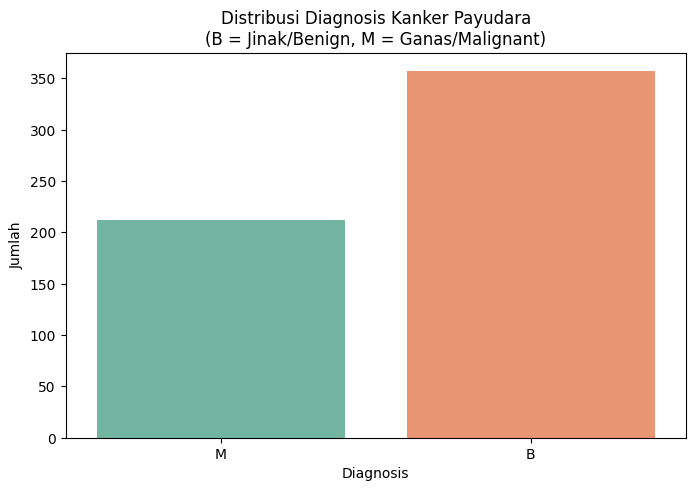

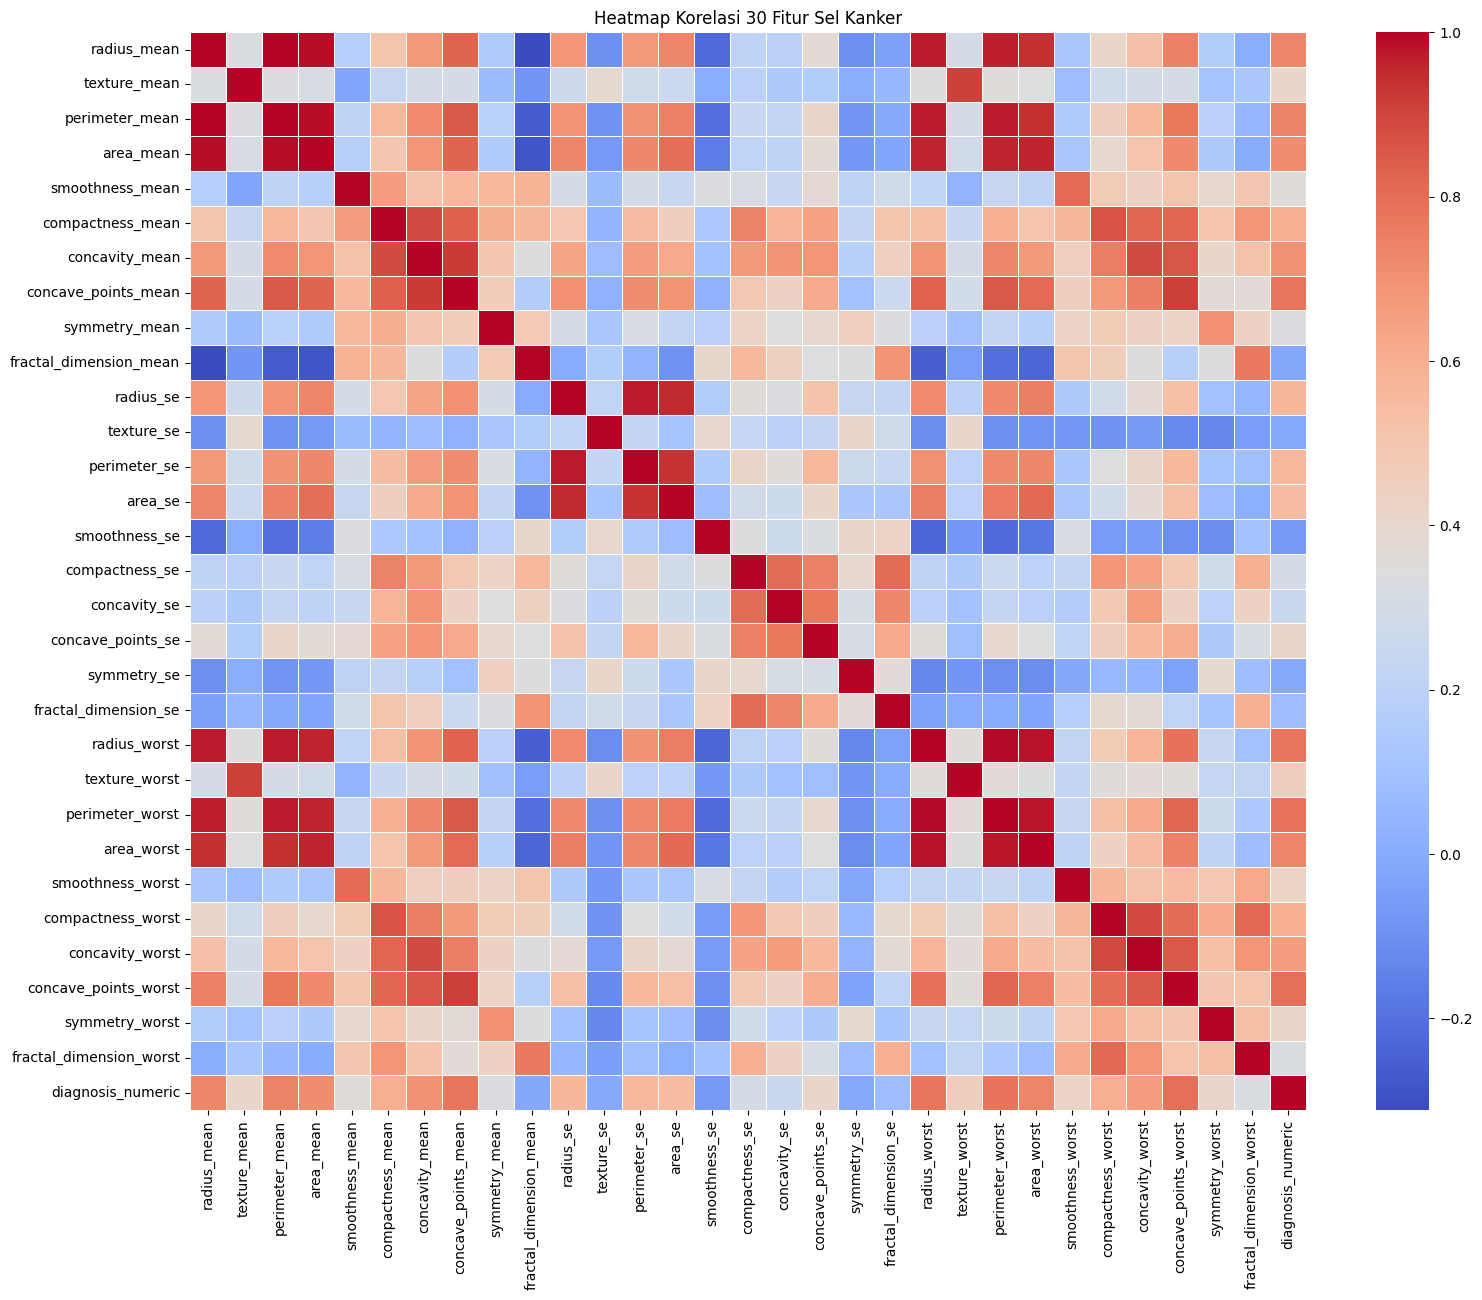

In [ ]:
# Mengecek Informasi Dasar dan Data Kosong
print("--- INFORMASI DATASET ---")
df.info()
print("\n--- JUMLAH DATA KOSONG (MISSING VALUES) ---")
print(df.isnull().sum().sum(), "missing values ditemukan.")

# Visualisasi 1: Distribusi Target (Diagnosis)
plt.figure(figsize=(8, 5))
# Kita buat grafik untuk melihat perbandingan diagnosis M (Malignant) dan B (Benign)
sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title('Distribusi Diagnosis Kanker Payudara\n(B = Jinak/Benign, M = Ganas/Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Jumlah')
plt.show()

# Mengubah target teks menjadi angka untuk analisis korelasi (M=1, B=0)
df['diagnosis_numeric'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Visualisasi 2: Heatmap Korelasi
plt.figure(figsize=(18, 14))
# Menghapus kolom 'diagnosis' teks agar tidak error saat korelasi
corr_matrix = df.drop('diagnosis', axis=1).corr()

# Menggambar heatmap tanpa angka agar warna terlihat jelas
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi 30 Fitur Sel Kanker')
plt.show()

# Hapus kolom bantuan numerik agar dataset kembali ke bentuk asal jika ingin diproses lebih lanjut
df.drop('diagnosis_numeric', axis=1, inplace=True)

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
print("--- MEMULAI DATA PREPROCESSING ---")

# 1. Menangani Duplikat
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat sebelum dibersihkan: {jumlah_duplikat}")
df = df.drop_duplicates()

# 2. Encoding Data Kategorikal (Target 'diagnosis')
# Pastikan kolom diagnosis masih berupa huruf 'M' atau 'B' saat kode ini dijalankan
if df['diagnosis'].dtype == 'object':
    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
    print("Encoding target 'diagnosis' berhasil (M=1, B=0).")

# 3. Memisahkan Fitur (X) dan Target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# 4. Standarisasi / Normalisasi Fitur menggunakan StandardScaler
scaler = StandardScaler()

# Mengubah data asli (X) menjadi data dengan skala yang setara (X_scaled)
X_scaled = scaler.fit_transform(X)

# Mengembalikan hasil standarisasi ke dalam bentuk DataFrame agar mudah dibaca
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nData berhasil distandarisasi! Berikut 5 baris pertama data yang sudah siap masuk model:")
display(X_scaled_df.head())

--- MEMULAI DATA PREPROCESSING ---
Jumlah baris duplikat sebelum dibersihkan: 0
Encoding target 'diagnosis' berhasil (M=1, B=0).

Data berhasil distandarisasi! Berikut 5 baris pertama data yang sudah siap masuk model:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [ ]:
# 1. Menggabungkan kembali fitur yang sudah distandarisasi (X_scaled) dengan target (y)
df_preprocessed = X_scaled_df.copy()

# Menggunakan .values agar urutan barisnya sejajar dan tidak berantakan
df_preprocessed['diagnosis'] = y.values

# 2. Menyimpan DataFrame menjadi file CSV baru
nama_file = 'wdbc_preprocessed.csv'
df_preprocessed.to_csv(nama_file, index=False)

print(f"Mantap! Data berhasil disimpan dengan nama: {nama_file}")

Mantap! Data berhasil disimpan dengan nama: wdbc_preprocessed.csv
